# Dataset & fold sanity checks: age, sex, and QC

Goal: verify whether the **patient-wise, (label × dataset)-stratified folds** preserve the **age**, **sex**, and **ECG quality** distributions.

Important context for interpretation:
- **CODE-15%** is the dominant dataset (~300k ECGs).
- **SaMi-Trop** is **all positive** (~1.6k ECGs).
- **PTB-XL** is **all negative** (~20k ECGs).

Because of the large size differences, most plots below use **percentages / within-source normalization** so the 5 folds can be compared on equal footing.

This is shown in four layers:
1. **Overall dataset structure** (rows, sources, label balance, missingness).
2. **Per-fold structure** (counts and label balance by source, normalized for comparability).
3. **Age/Sex drift checks** (per fold vs overall, within each source and label stratum).
4. **ECG quality drift checks** (templatematch bins and Zhao 2018 categories).

Notes:
- Some sources are **uni-labeled** (PTB-XL all `chagas=0`, SaMi-Trop all `chagas=1`). That’s expected; I still want them evenly spread across folds.
- I treat PTB-XL “HIPAA-masked” ages (`>=300`) as age `90` for visualization.


In [47]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    def display(*args, **kwargs):
        return None

sns.set_theme(context='talk', style='whitegrid')
sns.set_palette('colorblind')

# --- Configure metadata path ---
# You can also set an env var: META_PATH=/path/to/metadata.csv
META_PATH = Path(os.environ.get(
    'META_PATH',
    '/home/flo178/projects/master-thesis/datasets/physionet2025/processedMaster/metadata.csv'
))

if not META_PATH.is_file():
    raise FileNotFoundError(
        f"Metadata CSV not found: {META_PATH}. "
        "Set META_PATH env var or update META_PATH in this notebook."
    )

df = pd.read_csv(META_PATH, low_memory=False)

required = {'exam_id', 'age', 'sex', 'chagas', 'source', 'fold'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in metadata: {sorted(missing)}")

# --- Clean/normalize columns ---
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# PTB-XL HIPAA mask: ages > 89 may appear as 300+.
# We cap them to 90 for visualization/grouping.
df.loc[df['age'] >= 300, 'age'] = 90

# Normalize sex into {Male, Female, Unknown}
# - CODE-15 / SaMi-Trop: is_male True/False
# - PTB-XL: sex 0/1 (0=male, 1=female)
# - Some rows may already be strings 'Male'/'Female'

def normalize_sex(val):
    if pd.isna(val):
        return 'Unknown'
    if isinstance(val, bool):
        return 'Male' if val else 'Female'
    if isinstance(val, (int, float, np.integer, np.floating)):
        if val == 0:
            return 'Male'
        if val == 1:
            return 'Female'
        return 'Unknown'
    if isinstance(val, str):
        v = val.strip().lower()
        if v.startswith('m'):
            return 'Male'
        if v.startswith('f'):
            return 'Female'
    return 'Unknown'

df['sex_norm'] = df['sex'].apply(normalize_sex)

# Make sure fold is integer-ish
if not np.issubdtype(df['fold'].dtype, np.number):
    df['fold'] = pd.to_numeric(df['fold'], errors='coerce')

df['fold'] = df['fold'].astype('Int64')


def ordered_sources(series: pd.Series) -> list[str]:
    preferred = ['CODE-15%', 'CODE-15', 'SaMi-Trop', 'Sami-Trop', 'PTB-XL']
    existing = [x for x in pd.unique(series.dropna())]
    ordered = [s for s in preferred if s in existing]
    ordered += [s for s in sorted(existing) if s not in ordered]
    return ordered


def ordered_folds(series: pd.Series) -> list[int]:
    return sorted(pd.unique(series.dropna().astype(int)).tolist())


print('Rows:', len(df))
print('Sources:', df['source'].nunique())
print('Folds:', df['fold'].nunique())

df.head()


Rows: 366185
Sources: 3
Folds: 5


,exam_id,age,sex,chagas,source,path,resample_method,qc_zhao2018_bp,qc_templatematch_bp,patient_id,fold,proc_stem,processed_root,sex_norm
0,1103441,50,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Excellent,0.921019,1103441,1,1103441,/home/flo178/projects/master-thesis/datasets/p...,Female
1,392056,24,Male,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Excellent,0.995079,392056,1,392056,/home/flo178/projects/master-thesis/datasets/p...,Male
2,411968,72,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Unacceptable,0.991599,411968,0,411968,/home/flo178/projects/master-thesis/datasets/p...,Female
3,956206,63,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Excellent,0.990780,956206,3,956206,/home/flo178/projects/master-thesis/datasets/p...,Female
4,2848422,69,Female,0,CODE-15%,/home/flo178/projects/master-thesis/datasets/p...,Cached,Excellent,0.986983,2848422,2,2848422,/home/flo178/projects/master-thesis/datasets/p...,Female


## CODE-15 label coverage check

This checks whether `code15_chagas_labels.csv` contains duplicate `exam_id`s and whether all labeled exams were exported/processed into the WFDB tree (i.e., appear in `metadata.csv`).


In [48]:
# --- CODE-15 label coverage check ---
# Expected location: <physionet_root>/code15/code15_chagas_labels.csv

physionet_root = META_PATH.parent.parent  # .../physionet2025
labels_path = physionet_root / 'code15' / 'code15_chagas_labels.csv'
print('Looking for:', labels_path)

if not labels_path.is_file():
    print('Missing labels CSV. Update labels_path if your folder differs.')
else:
    lab = pd.read_csv(labels_path)
    if 'exam_id' not in lab.columns:
        raise ValueError(f"Expected 'exam_id' column in {labels_path}, got: {list(lab.columns)}")

    n_rows = len(lab)
    n_unique = lab['exam_id'].nunique(dropna=True)
    n_dupes = n_rows - n_unique

    print('labels rows:', n_rows)
    print('unique exam_id:', n_unique)
    print('duplicate rows:', n_dupes)

    # Compare to metadata
    code_meta = df[df['source'].astype(str).isin({'CODE-15%', 'CODE-15'})].copy()
    meta_exam_ids = set(code_meta['exam_id'].astype(str))
    label_exam_ids = set(lab['exam_id'].astype(str))

    missing_in_meta = sorted(label_exam_ids - meta_exam_ids)
    extra_in_meta = sorted(meta_exam_ids - label_exam_ids)

    print('CODE-15 exams in metadata:', len(meta_exam_ids))
    print('CODE-15 labeled exam_ids:', len(label_exam_ids))
    print('labeled but missing in metadata:', len(missing_in_meta))
    print('in metadata but not in labels:', len(extra_in_meta))

    if missing_in_meta:
        print('Example missing exam_ids:', missing_in_meta[:10])

    if extra_in_meta:
        print('Example extra exam_ids:', extra_in_meta[:10])

Looking for: /home/flo178/projects/master-thesis/datasets/physionet2025/code15/code15_chagas_labels.csv
labels rows: 343424
unique exam_id: 343424
duplicate rows: 0
CODE-15 exams in metadata: 342755
CODE-15 labeled exam_ids: 343424
labeled but missing in metadata: 669
in metadata but not in labels: 0
Example missing exam_ids: ['1006606', '1012984', '1015802', '102019', '1023545', '1024570', '1026433', '1027242', '1032169', '1042196']


## 1) Overall dataset structure

We start by checking:
- sample counts by `source` and `chagas`
- missingness in `age` / `sex_norm`

Because CODE-15% dwarfs the other datasets, plots below use **log scale** for raw counts and **percentages** for balance metrics.


In [49]:
# Counts by source × label
counts = (
    df.groupby(['source', 'chagas'])['exam_id']
      .count()
      .rename('n')
      .reset_index()
)

display(counts.sort_values(['source', 'chagas']))

# Pivot for quick view
pivot_counts = counts.pivot_table(index='source', columns='chagas', values='n', fill_value=0)
display(pivot_counts)

# Missingness
missingness = pd.DataFrame({
    'n_rows': df.groupby('source').size(),
    'age_missing_frac': df.groupby('source')['age'].apply(lambda s: s.isna().mean()),
    'sex_unknown_frac': df.groupby('source')['sex_norm'].apply(lambda s: (s=='Unknown').mean()),
})

display(missingness)

,source,chagas,n
0,CODE-15%,0,336196
1,CODE-15%,1,6559
2,PTB-XL,0,21799
3,SaMi-Trop,1,1631


chagas,0,1
source,,
CODE-15%,336196.0,6559.0
PTB-XL,21799.0,0.0
SaMi-Trop,0.0,1631.0


,n_rows,age_missing_frac,sex_unknown_frac
source,,,
CODE-15%,342755,0.0,0.0
PTB-XL,21799,0.0,0.0
SaMi-Trop,1631,0.0,0.0


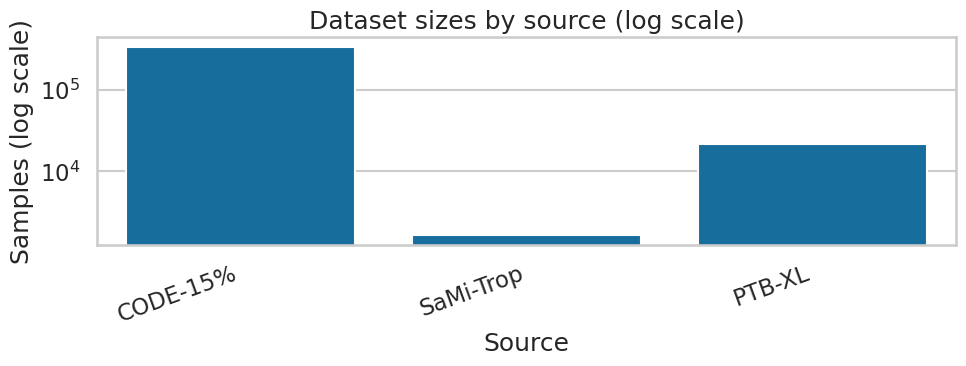

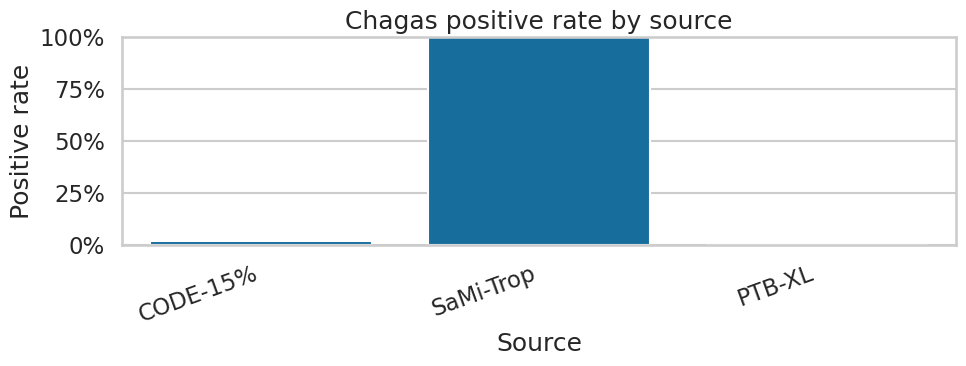

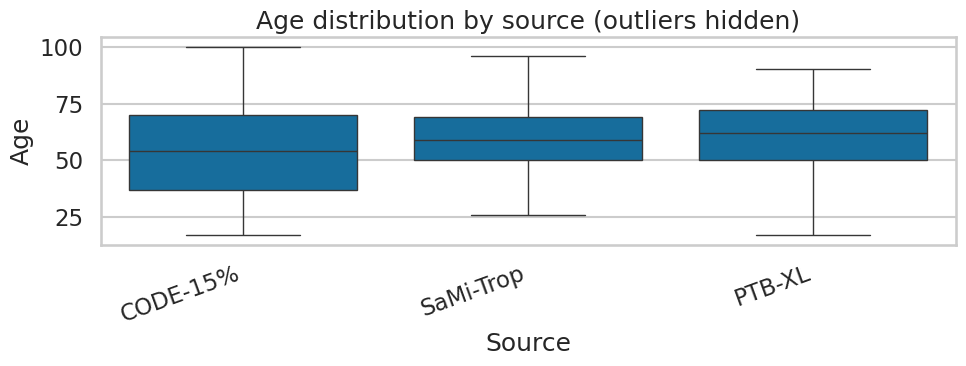

In [50]:
# Plot: dataset size (log scale) + label balance per source
src_order = ordered_sources(df['source'])

source_counts = (
    df.groupby('source')['exam_id']
      .count()
      .reindex(src_order)
      .rename('n')
      .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.barplot(data=source_counts, x='source', y='n', order=src_order, ax=ax)
ax.set_yscale('log')
ax.set_title('Dataset sizes by source (log scale)')
ax.set_xlabel('Source')
ax.set_ylabel('Samples (log scale)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Plot: label balance per source
pos_rate = (
    df.groupby('source')['chagas']
      .mean()
      .reindex(src_order)
      .rename('pos_rate')
      .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.barplot(data=pos_rate, x='source', y='pos_rate', order=src_order, ax=ax)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title('Chagas positive rate by source')
ax.set_xlabel('Source')
ax.set_ylabel('Positive rate')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Plot: age distribution by source (boxplot)
age_df = df[df['age'].notna()].copy()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.boxplot(data=age_df, x='source', y='age', order=src_order, ax=ax, showfliers=False)
ax.set_title('Age distribution by source (outliers hidden)')
ax.set_xlabel('Source')
ax.set_ylabel('Age')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## 2) Fold structure (counts and label balance)

Because folds are stratified on `(chagas, source)` and grouped by `patient_id`, I expect:
- each `source` to be evenly spread across folds
- within CODE-15, the `chagas` prevalence to be very similar across folds

To make folds comparable despite size differences, we show **within-source percentages** and **fold-normalized rates**.


In [51]:
# Count per fold × source
fold_source_counts = df.groupby(['fold', 'source']).size().rename('n').reset_index()
display(fold_source_counts.pivot_table(index='fold', columns='source', values='n', fill_value=0))

# Chagas prevalence per fold × source
fold_source_pos = (
    df.groupby(['fold', 'source'])['chagas']
      .mean()
      .rename('pos_rate')
      .reset_index()
)
display(fold_source_pos.pivot_table(index='fold', columns='source', values='pos_rate'))

source,CODE-15%,PTB-XL,SaMi-Trop
fold,,,
0,68521.0,4371.0,345.0
1,68607.0,4289.0,341.0
2,68505.0,4393.0,340.0
3,68530.0,4414.0,293.0
4,68592.0,4332.0,312.0


source,CODE-15%,PTB-XL,SaMi-Trop
fold,,,
0,0.018753,0.0,1.0
1,0.018774,0.0,1.0
2,0.019473,0.0,1.0
3,0.019451,0.0,1.0
4,0.019230,0.0,1.0


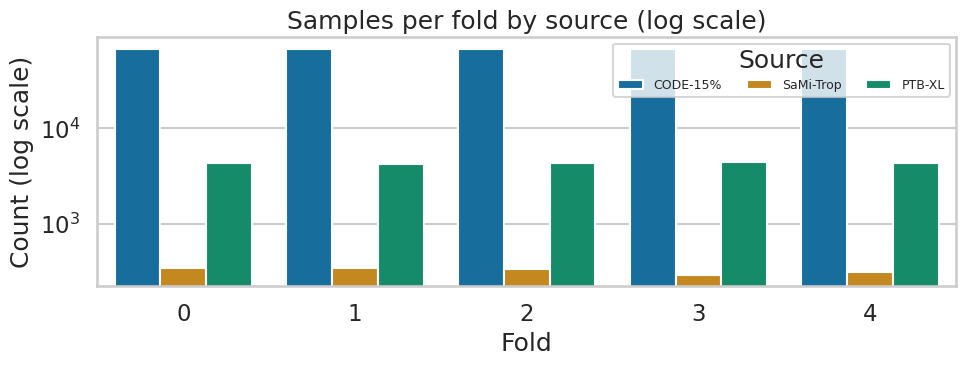

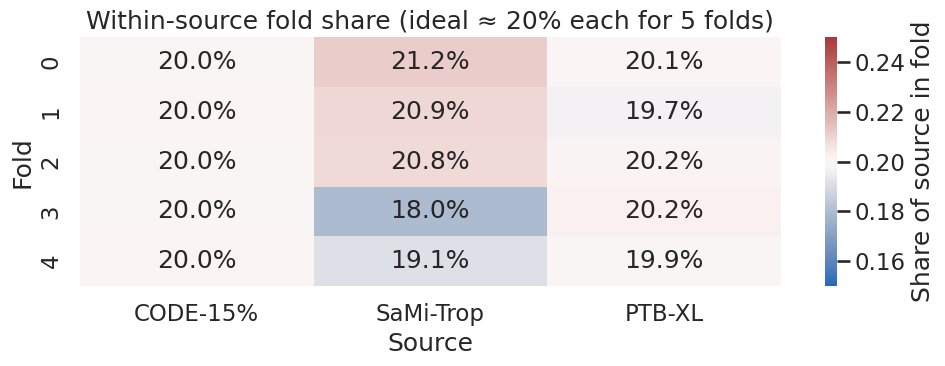

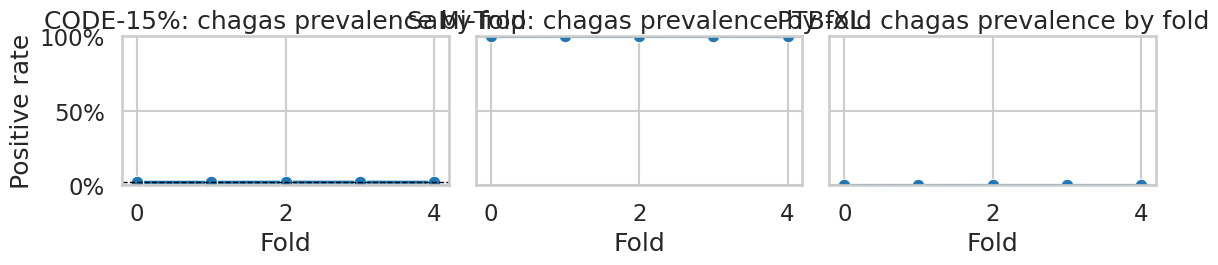

In [52]:
# Plot: samples per fold for each source (log scale for visibility)
fold_order = ordered_folds(df['fold'])
src_order = ordered_sources(df['source'])

fold_source_counts = (
    df.groupby(['fold', 'source']).size()
      .rename('n')
      .reset_index()
)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.barplot(
    data=fold_source_counts,
    x='fold',
    y='n',
    hue='source',
    order=fold_order,
    hue_order=src_order,
    ax=ax,
)
ax.set_yscale('log')
ax.set_title('Samples per fold by source (log scale)')
ax.set_xlabel('Fold')
ax.set_ylabel('Count (log scale)')
ax.legend(title='Source', ncols=3, fontsize=9)
plt.tight_layout()
plt.show()

# Plot: within-source fold share (percentage) as a heatmap
fold_source_counts['source_total'] = fold_source_counts.groupby('source')['n'].transform('sum')
fold_source_counts['within_source_pct'] = fold_source_counts['n'] / fold_source_counts['source_total']

heat = fold_source_counts.pivot_table(
    index='fold', columns='source', values='within_source_pct', fill_value=0
).reindex(index=fold_order, columns=src_order)

expected = 1 / max(len(fold_order), 1)
vmin = max(0, expected - 0.05)
vmax = min(1, expected + 0.05)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
sns.heatmap(
    heat,
    cmap='vlag',
    vmin=vmin,
    vmax=vmax,
    annot=True,
    fmt='.1%',
    cbar_kws={'label': 'Share of source in fold'},
    ax=ax,
)
ax.set_title('Within-source fold share (ideal ≈ 20% each for 5 folds)')
ax.set_xlabel('Source')
ax.set_ylabel('Fold')
plt.tight_layout()
plt.show()

# Plot: chagas prevalence per fold × source (percent)
fold_source_pos = (
    df.groupby(['fold', 'source'])['chagas']
      .mean()
      .rename('pos_rate')
      .reset_index()
)

# Facet by source so all-positive / all-negative datasets are still interpretable
ncols = 3
nrows = int(np.ceil(len(src_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(3, 2.5 * nrows)), sharey=True)
axes = np.array(axes).reshape(-1)

for ax, src in zip(axes, src_order):
    sub = fold_source_pos[fold_source_pos['source'] == src].copy()
    sns.lineplot(
        data=sub,
        x='fold',
        y='pos_rate',
        marker='o',
        sort=False,
        ax=ax,
        color='tab:blue',
    )
    ref = df.loc[df['source'] == src, 'chagas'].mean()
    ax.axhline(ref, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{src}: chagas prevalence by fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Positive rate')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Hide extra axes
for ax in axes[len(src_order):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Leakage check: `patient_id` across folds (within source)

This flags any `(source, patient_id)` that appears in more than one `fold`.
If this table is non-empty, I have patient leakage across folds.


In [53]:
# --- Leakage check: (source, patient_id) in multiple folds ---

required = {'patient_id', 'source', 'fold'}
missing = required - set(df.columns)
if missing:
    print('Missing required columns for leakage check:', sorted(missing))
else:
    base = df.dropna(subset=['patient_id', 'source', 'fold']).copy()

    leak = (
        base.groupby(['source', 'patient_id'])
            .agg(
                n_exams=('exam_id', 'size') if 'exam_id' in base.columns else ('fold', 'size'),
                n_folds=('fold', lambda s: s.nunique()),
                folds=('fold', lambda s: sorted([int(x) for x in pd.unique(s.dropna())])),
            )
            .reset_index()
    )

    leak = leak[leak['n_folds'] > 1].sort_values(
        ['source', 'n_folds', 'n_exams'], ascending=[True, False, False]
    )

    print('Patients from the same source appearing in >1 fold:', len(leak))
    if len(leak) == 0:
        print('OK: no (source, patient_id) appears in multiple folds.')
    else:
        display(leak)
        display(leak.groupby('source').size().rename('n_patients_in_multiple_folds'))

    # Optional: also check patient_id globally (regardless of source)
    global_leak = (
        base.groupby('patient_id')
            .agg(
                n_sources=('source', lambda s: s.nunique()),
                n_folds=('fold', lambda s: s.nunique()),
                sources=('source', lambda s: sorted(pd.unique(s.dropna()).tolist())),
                folds=('fold', lambda s: sorted([int(x) for x in pd.unique(s.dropna())])),
            )
            .reset_index()
    )
    global_leak = global_leak[global_leak['n_folds'] > 1].sort_values(['n_folds', 'n_sources'], ascending=[False, False])

    print('Patient IDs appearing in >1 fold overall:', len(global_leak))
    if len(global_leak) > 0:
        display(global_leak.head(50))


Patients from the same source appearing in >1 fold: 0
OK: no (source, patient_id) appears in multiple folds.
Patient IDs appearing in >1 fold overall: 0


## 3) Does each fold preserve age and sex?

We compare each fold to the overall distribution **within each source**, and also within each `(source, chagas)` stratum.

We use simple drift summaries:
- `age_mean` / `age_median` per fold vs overall
- `male_rate` per fold vs overall (excluding `Unknown`)

If you see big swings, it means stratification preserved labels/sources but not necessarily demographics.


In [54]:
# Helper: male rate excluding Unknown

def male_rate(series: pd.Series) -> float:
    s = series[series != 'Unknown']
    if len(s) == 0:
        return np.nan
    return (s == 'Male').mean()

# Overall per source (reference)
ref = (
    df.groupby('source')
      .agg(
          n=('exam_id', 'size'),
          age_mean=('age', 'mean'),
          age_median=('age', 'median'),
          male_rate=('sex_norm', male_rate),
      )
)

display(ref)

# Per fold per source
per_fold = (
    df.groupby(['source', 'fold'])
      .agg(
          n=('exam_id', 'size'),
          age_mean=('age', 'mean'),
          age_median=('age', 'median'),
          male_rate=('sex_norm', male_rate),
      )
      .reset_index()
)

# Join to compute deltas vs reference
per_fold = per_fold.merge(ref.reset_index(), on='source', suffixes=('', '_ref'))
per_fold['age_mean_delta'] = per_fold['age_mean'] - per_fold['age_mean_ref']
per_fold['age_median_delta'] = per_fold['age_median'] - per_fold['age_median_ref']
per_fold['male_rate_delta'] = per_fold['male_rate'] - per_fold['male_rate_ref']

display(per_fold.sort_values(['source', 'fold']))

# Summary of absolute drift per source
summary = (
    per_fold.groupby('source')
      .agg(
          max_abs_age_mean_delta=('age_mean_delta', lambda s: np.nanmax(np.abs(s))),
          max_abs_age_median_delta=('age_median_delta', lambda s: np.nanmax(np.abs(s))),
          max_abs_male_rate_delta=('male_rate_delta', lambda s: np.nanmax(np.abs(s))),
      )
)

display(summary)

,n,age_mean,age_median,male_rate
source,,,,
CODE-15%,342755,53.187869,54.0,0.403052
PTB-XL,21799,59.946695,62.0,0.520850
SaMi-Trop,1631,59.397302,59.0,0.327406


,source,fold,n,age_mean,age_median,male_rate,n_ref,age_mean_ref,age_median_ref,male_rate_ref,age_mean_delta,age_median_delta,male_rate_delta
0,CODE-15%,0,68521,53.285547,55.0,0.402811,342755,53.187869,54.0,0.403052,0.097679,1.0,-0.000241
1,CODE-15%,1,68607,53.197764,54.0,0.402976,342755,53.187869,54.0,0.403052,0.009895,0.0,-0.000075
2,CODE-15%,2,68505,53.122020,54.0,0.401314,342755,53.187869,54.0,0.403052,-0.065849,0.0,-0.001738
3,CODE-15%,3,68530,53.067547,54.0,0.405443,342755,53.187869,54.0,0.403052,-0.120322,0.0,0.002391
4,CODE-15%,4,68592,53.266372,54.0,0.402715,342755,53.187869,54.0,0.403052,0.078503,0.0,-0.000337
5,PTB-XL,0,4371,59.782201,61.0,0.527568,21799,59.946695,62.0,0.520850,-0.164494,-1.0,0.006718
6,PTB-XL,1,4289,60.103054,62.0,0.520634,21799,59.946695,62.0,0.520850,0.156360,0.0,-0.000215
7,PTB-XL,2,4393,59.614387,61.0,0.521056,21799,59.946695,62.0,0.520850,-0.332308,-1.0,0.000207
8,PTB-XL,3,4414,59.672859,61.0,0.527866,21799,59.946695,62.0,0.520850,-0.273836,-1.0,0.007016
9,PTB-XL,4,4332,60.573869,63.0,0.506925,21799,59.946695,62.0,0.520850,0.627174,1.0,-0.013924


,max_abs_age_mean_delta,max_abs_age_median_delta,max_abs_male_rate_delta
source,,,
CODE-15%,0.120322,1.0,0.002391
PTB-XL,0.627174,1.0,0.013924
SaMi-Trop,1.234983,1.0,0.037551


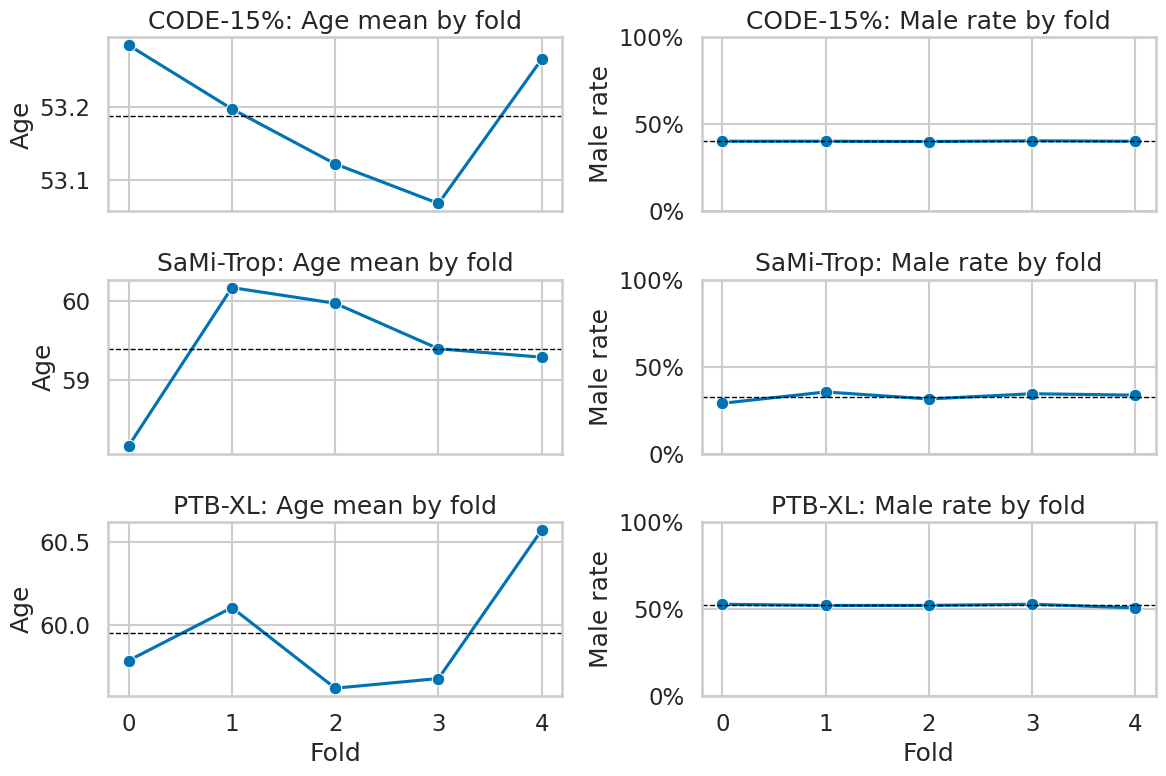

In [55]:
# Plot: age mean and male rate per fold with overall reference, per source
src_order = ordered_sources(df['source'])
fold_order = ordered_folds(df['fold'])

n_src = len(src_order)
metrics = ['age_mean', 'male_rate']
metric_titles = {'age_mean': 'Age mean by fold', 'male_rate': 'Male rate by fold'}

fig, axes = plt.subplots(n_src, 2, figsize=(12, max(3, 2.7 * n_src)), sharex=True)
if n_src == 1:
    axes = np.array([axes])

for r, src in enumerate(src_order):
    sub = per_fold[per_fold['source'] == src]

    for c, metric in enumerate(metrics):
        ax = axes[r, c]
        sns.lineplot(
            data=sub,
            x='fold',
            y=metric,
            marker='o',
            sort=False,
            ax=ax,
        )
        ref_val = ref.loc[src, metric]
        if not np.isnan(ref_val):
            ax.axhline(ref_val, color='black', linestyle='--', linewidth=1)
        ax.set_title(f"{src}: {metric_titles[metric]}")
        ax.set_xlabel('Fold')
        ax.set_ylabel('Age' if metric == 'age_mean' else 'Male rate')
        if metric == 'male_rate':
            ax.set_ylim(0, 1)
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()


### Optional: demographic drift within each (source, chagas) stratum

Since folds are stratified on `(source, chagas)`, it can also be useful to check age/sex drift **within** those strata.
This matters most for datasets with both labels (typically CODE-15).

,source,chagas,fold,n,age_mean,male_rate
0,CODE-15%,0,0,67236,53.147793,0.403370
1,CODE-15%,0,1,67319,53.051724,0.403541
2,CODE-15%,0,2,67171,52.987227,0.402242
3,CODE-15%,0,3,67197,52.909535,0.406476
4,CODE-15%,0,4,67273,53.134289,0.403401
5,CODE-15%,1,0,1285,60.493385,0.373541
6,CODE-15%,1,1,1288,60.830745,0.373447
7,CODE-15%,1,2,1334,59.909295,0.354573
8,CODE-15%,1,3,1333,61.033008,0.353338
9,CODE-15%,1,4,1319,60.003033,0.367703


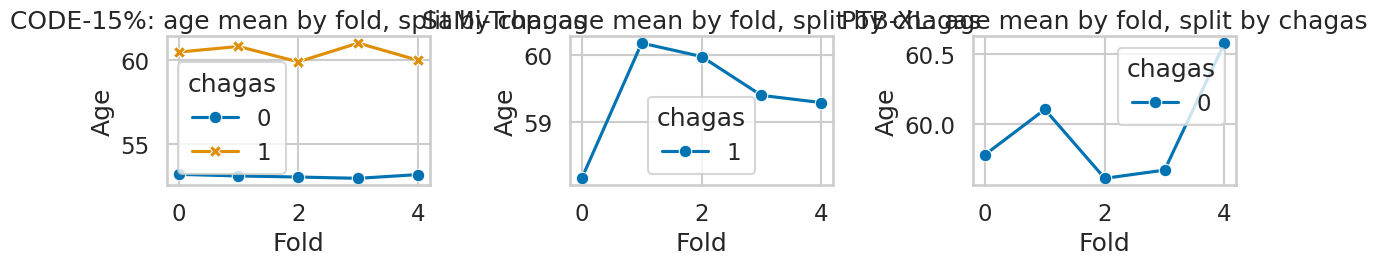

In [56]:
strata = (
    df.groupby(['source', 'chagas', 'fold'])
      .agg(
          n=('exam_id', 'size'),
          age_mean=('age', 'mean'),
          male_rate=('sex_norm', lambda s: (s[s!='Unknown']=='Male').mean() if (s!='Unknown').any() else np.nan),
      )
      .reset_index()
)

display(strata.sort_values(['source', 'chagas', 'fold']))

# Quick visualization: for each source, plot age mean per fold split by chagas
src_order = ordered_sources(df['source'])
fold_order = ordered_folds(df['fold'])

ncols = 3
nrows = int(np.ceil(len(src_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(3, 2.6 * nrows)), sharey=False)
axes = np.array(axes).reshape(-1)

for ax, src in zip(axes, src_order):
    sub = strata[strata.source == src]
    sns.lineplot(
        data=sub,
        x='fold',
        y='age_mean',
        hue='chagas',
        style='chagas',
        markers=True,
        dashes=False,
        sort=False,
        ax=ax,
    )
    ax.set_title(f'{src}: age mean by fold, split by chagas')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Age')

# Hide extra axes
for ax in axes[len(src_order):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


## 4) ECG quality checks by fold

These plots focus on the QC fields produced during preprocessing:
- `qc_templatematch_bp` (continuous 0–1): we bin into categories and compare fold histograms.
- `qc_zhao2018_bp` (categorical): we compare fold-wise stacked bars.

The goal is not identical distributions, but **no fold stands out** as systematically worse or better.


/tmp/ipykernel_220301/2721879709.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  qc_df.groupby(['fold', 'templatematch_bin']).size().rename('n').reset_index()


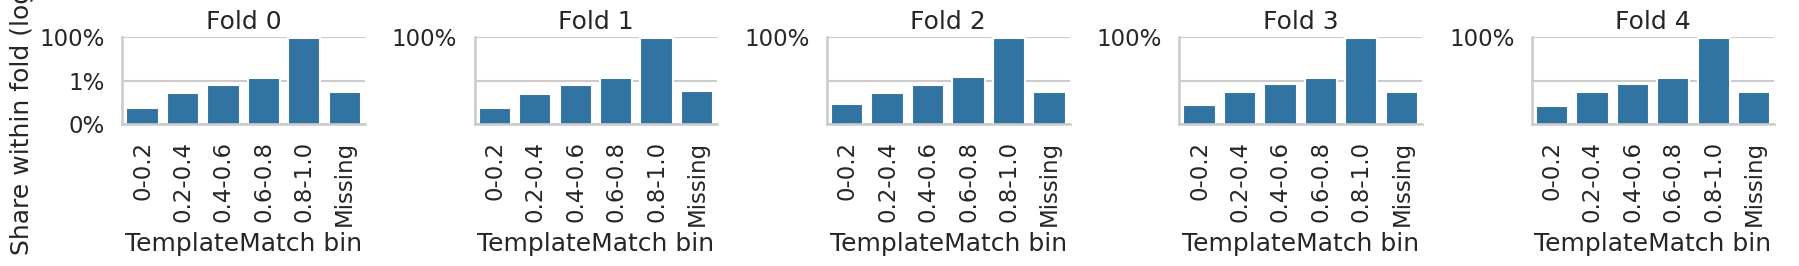

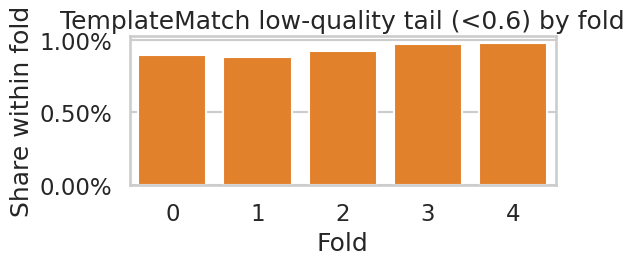

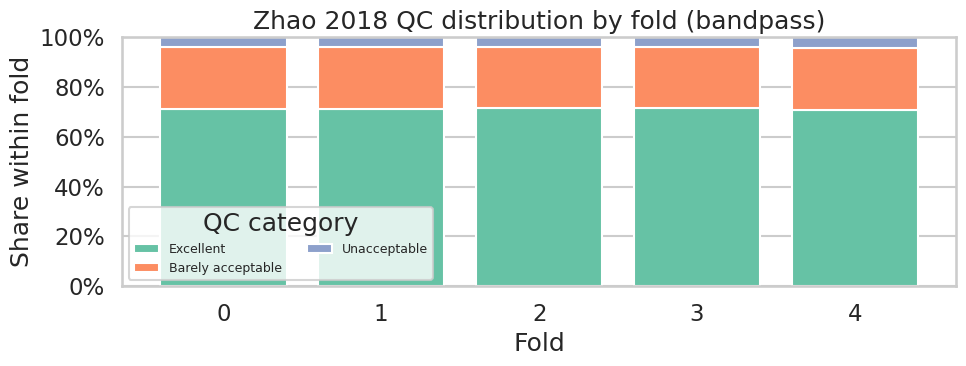

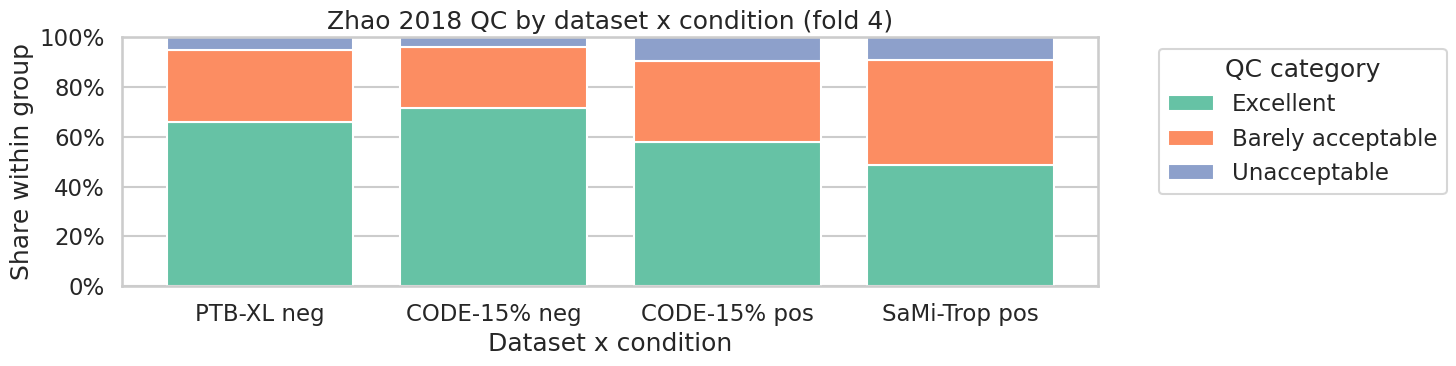

Contingency table for source: CODE-15%
chagas                 0    1
qc_zhao2018_bp               
Barely acceptable  16464  429
Excellent          48189  764
Unacceptable        2618  126


chagas,0,1
qc_zhao2018_bp,,
Barely acceptable,16464,429
Excellent,48189,764
Unacceptable,2618,126


2x2 Fisher (Excellent vs Not): OR=1.835, p=7.87e-26
3x2 FFH Monte-Carlo p≈0
Zhao2018 QC counts and percentages by dataset x condition (fold 4):


count                                   pct(%)  \
zhao_cat      Excellent Barely acceptable Unacceptable Excellent   
group                                                              
PTB-XL neg         2852              1260          220     65.84   
CODE-15% neg      48189             16464         2618     71.63   
CODE-15% pos        764               429          126     57.92   
SaMi-Trop pos       152               131           29     48.72   

                                              
zhao_cat      Barely acceptable Unacceptable  
group                                         
PTB-XL neg                29.09         5.08  
CODE-15% neg              24.47         3.89  
CODE-15% pos              32.52         9.55  
SaMi-Trop pos             41.99         9.29

In [57]:
qc_cols = {'qc_zhao2018_bp', 'qc_templatematch_bp'}
missing_qc = qc_cols - set(df.columns)

if missing_qc:
    print('Missing QC columns:', sorted(missing_qc))
else:
    qc_df = df[['fold', 'source', 'chagas', 'qc_zhao2018_bp', 'qc_templatematch_bp']].copy()

    # --- templatematch bins ---
    qc_df['qc_templatematch_bp'] = pd.to_numeric(qc_df['qc_templatematch_bp'], errors='coerce')
    tm_bins = [0, 0.2, 0.4, 0.6, 0.8, 1.01]
    tm_labels = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
    qc_df['templatematch_bin'] = pd.cut(
        qc_df['qc_templatematch_bp'],
        bins=tm_bins,
        labels=tm_labels,
        include_lowest=True,
        right=False,
    )
    qc_df['templatematch_bin'] = qc_df['templatematch_bin'].cat.add_categories(['Missing']).fillna('Missing')

    tm_counts = (
        qc_df.groupby(['fold', 'templatematch_bin']).size().rename('n').reset_index()
    )
    tm_counts['fold_total'] = tm_counts.groupby('fold')['n'].transform('sum')
    tm_counts['pct'] = tm_counts['n'] / tm_counts['fold_total']
    tm_counts['pct_plot'] = tm_counts['pct'].replace(0, np.nan)

    fold_order = ordered_folds(df['fold'])
    tm_order = tm_labels + ['Missing']

    g = sns.catplot(
        data=tm_counts,
        x='templatematch_bin',
        y='pct_plot',
        col='fold',
        col_wrap=5,
        order=tm_order,
        kind='bar',
        color='tab:blue',
        height=3,
        aspect=1.2,
        sharey=True,  # share y axis across facets
    )
    g.set_titles('Fold {col_name}')
    g.set_axis_labels('TemplateMatch bin', 'Share within fold (log scale)')
    # apply log scale and common limits to all facets
    g.set(yscale='log', ylim=(1e-4, 1))
    for ax in g.axes.flatten():
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()

    # Highlight the low-quality tail (<0.6) per fold
    low_bins = ['0.0-0.2', '0.2-0.4', '0.4-0.6']
    low = tm_counts[tm_counts['templatematch_bin'].isin(low_bins)].copy()
    low_share = (
        low.groupby('fold')['pct']
           .sum()
           .reindex(fold_order)
           .rename('low_share')
           .reset_index()
    )

    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    sns.barplot(data=low_share, x='fold', y='low_share', ax=ax, color='tab:orange')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title('TemplateMatch low-quality tail (<0.6) by fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Share within fold')
    plt.tight_layout()
    plt.show()

    # --- Zhao 2018 QC stacked bars (by fold) ---
    zhao = qc_df['qc_zhao2018_bp'].astype('string')
    zhao = zhao.fillna('Missing')
    known = ['Excellent', 'Barely acceptable', 'Unacceptable']
    zhao = zhao.where(zhao.isin(known + ['Missing']), 'Other')
    zhao = zhao.astype('category')

    zhao_counts = pd.crosstab(qc_df['fold'], zhao, normalize='index')
    zhao_order = [c for c in ['Excellent', 'Barely acceptable', 'Unacceptable'] if c in zhao_counts.columns]
    zhao_counts = zhao_counts.reindex(index=fold_order, columns=zhao_order)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    bottom = np.zeros(len(zhao_counts))
    palette = sns.color_palette('Set2', n_colors=zhao_counts.shape[1])

    for (cat, color) in zip(zhao_counts.columns, palette):
        vals = zhao_counts[cat].values
        ax.bar(zhao_counts.index.astype(str), vals, bottom=bottom, label=cat, color=color)
        bottom += vals

    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 1)
    ax.set_title('Zhao 2018 QC distribution by fold (bandpass)')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Share within fold')
    ax.legend(title='QC category', ncols=2, fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- Zhao 2018 QC stacked bars by dataset x condition (not faceted) ---
    # groups: PTB-XL negative, CODE-15% negative, CODE-15% positive, SaMi-Trop positive
    df2 = qc_df[['source', 'chagas', 'qc_zhao2018_bp', 'fold']].copy()
    conds = [
        (df2['fold'] == 4) & (df2['source'] == 'PTB-XL') & (df2['chagas'] == 0),
        (df2['fold'] == 4) & (df2['source'] == 'CODE-15%') & (df2['chagas'] == 0),
        (df2['fold'] == 4) & (df2['source'] == 'CODE-15%') & (df2['chagas'] == 1),
        (df2['fold'] == 4) & (df2['source'] == 'SaMi-Trop') & (df2['chagas'] == 1),
    ]
    choices = ['PTB-XL neg', 'CODE-15% neg', 'CODE-15% pos', 'SaMi-Trop pos']
    df2['group'] = np.select(conds, choices, default='Missing')
    df2.loc[df2['group'] == 'Missing', 'group'] = np.nan
    df2 = df2.dropna(subset=['group'])

    z = df2['qc_zhao2018_bp'].astype('string').fillna('Missing')
    z = z.where(z.isin(known + ['Missing']), 'Other').astype('category')
    df2['zhao_cat'] = z

    cols = ['Excellent', 'Barely acceptable', 'Unacceptable']
    group_counts = pd.crosstab(df2['group'], df2['zhao_cat'], normalize='index').reindex(index=choices, columns=cols).fillna(0)

    fig, ax = plt.subplots(1, 1, figsize=(15, 4))
    bottom = np.zeros(len(group_counts))
    palette2 = sns.color_palette('Set2', n_colors=group_counts.shape[1])

    for (cat, color) in zip(group_counts.columns, palette2):
        vals = group_counts[cat].values
        ax.bar(group_counts.index, vals, bottom=bottom, label=cat, color=color)
        bottom += vals

    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylim(0, 1)
    ax.set_title('Zhao 2018 QC by dataset x condition (fold 4)')
    ax.set_xlabel('Dataset x condition')
    ax.set_ylabel('Share within group')
    ax.legend(title='QC category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # show contingency table for code 15 positives and negatives by their assigned zhao2018 quality score
    from scipy.stats import fisher_exact
    from statsmodels.stats.contingency_tables import Table
    results = []

    for source in ['CODE-15%']:
        tab = pd.crosstab(
            df2.loc[df2['source'] == source, 'qc_zhao2018_bp'],
            df2.loc[df2['source'] == source, 'chagas'],
        )

        # ensure all rows/cols exist
        for c in [0, 1]:
            if c not in tab.columns:
                tab[c] = 0
        # tab = tab.reindex(index=known + ['Other', 'Missing'], columns=[0, 1])

        # 2x2 Fisher: Excellent vs Not
        excellent = tab.loc['Excellent']
        not_excellent = tab.drop(index='Excellent').sum()
        fisher_table = np.array([
            [excellent[0], excellent[1]],
            [not_excellent[0], not_excellent[1]],
        ])
        or_val, p_fisher = fisher_exact(fisher_table)

        # 3x2 FFH Monte-Carlo
        ffh_table = tab.values
        strat_table = Table(ffh_table)
        ffh_res = strat_table.test_nominal_association()
        p_ffh = ffh_res.pvalue

        results.append({
            'source': source,
            'or_excellent_vs_not': or_val,
            'p_fisher': p_fisher,
            'p_ffh_monte_carlo': p_ffh,
        })

        print('Contingency table for source:', source)
        print(tab)
        # display contingency table and results
        from IPython.display import display
        display(tab)
        print('2x2 Fisher (Excellent vs Not): OR=%.3f, p=%.3g' % (or_val, p_fisher))
        print('3x2 FFH Monte-Carlo p≈%.3g' % p_ffh)

        # --- table of counts + percentages for Zhao 2018 QC by dataset x condition (fold 1) ---
        group_counts_abs = (
            pd.crosstab(df2["group"], df2["zhao_cat"])
            .reindex(index=choices, columns=cols)
            .fillna(0)
            .astype(int)
        )
        group_counts_pct = group_counts_abs.div(group_counts_abs.sum(axis=1), axis=0)

        table = pd.concat(
            [group_counts_abs, (group_counts_pct * 100).round(2)],
            keys=["count", "pct(%)"],
            axis=1,
        )

        from IPython.display import display

        print("Zhao2018 QC counts and percentages by dataset x condition (fold 4):")
        display(table)


## 5) Fold comparison across all metadata columns (excluding paths and IDs)

This section compares fold-wise distributions for every metadata column except IDs and path-like fields.
It prints:
- per-fold row counts
- per-fold missingness rates per column
- per-column distribution summaries (numeric vs categorical)


Comparing columns (excluding IDs/paths):
['age', 'sex_norm', 'chagas', 'source', 'resample_method', 'qc_zhao2018_bp', 'qc_templatematch_bp', 'sex_norm']


,n_rows
fold,
0,73237
1,73237
2,73238
3,73237
4,73236


,age__missing_%,sex_norm__missing_%,chagas__missing_%,source__missing_%,resample_method__missing_%,qc_zhao2018_bp__missing_%,qc_templatematch_bp__missing_%,sex_norm__missing_%
fold,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.01,0.26,0.0
1,0.0,0.0,0.0,0.0,0.0,0.01,0.29,0.0
2,0.0,0.0,0.0,0.0,0.0,0.01,0.28,0.0
3,0.0,0.0,0.0,0.0,0.0,0.00,0.29,0.0
4,0.0,0.0,0.0,0.0,0.0,0.00,0.28,0.0



age


,n_rows,n_non_missing,mean,std,min,q25,median,q75,max,missing_%
0,73237.0,73237.0,53.696260,19.582101,3.0,37.0,55.0,71.0,100.0,0.0
1,73237.0,73237.0,53.634638,19.619321,8.0,37.0,55.0,71.0,100.0,0.0
2,73238.0,73238.0,53.543256,19.586597,2.0,37.0,55.0,70.0,100.0,0.0
3,73237.0,73237.0,53.490968,19.594837,10.0,37.0,55.0,70.0,100.0,0.0
4,73236.0,73236.0,53.724275,19.581643,4.0,37.0,55.0,71.0,100.0,0.0
ALL,366185.0,366185.0,53.617879,19.592999,2.0,37.0,55.0,70.0,100.0,0.0


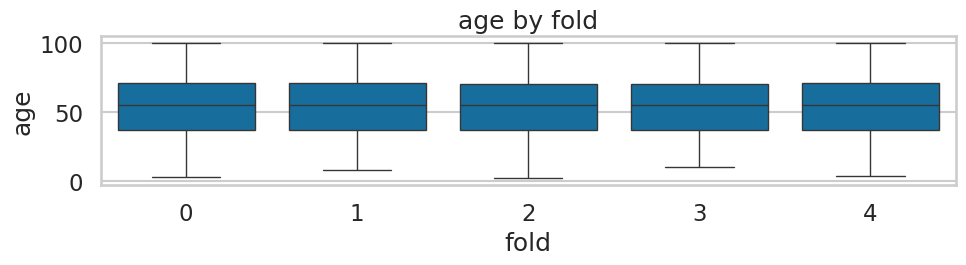


sex_norm
Categorical summary (% per fold):


sex_norm,Female,Male,NaN,Other
fold,,,,
0,59.03,40.97,0,0
1,59.04,40.96,0,0
2,59.19,40.81,0,0
3,58.74,41.26,0,0
4,59.14,40.86,0,0


Counts per fold:


sex_norm,Female,Male,NaN,Other
fold,,,,
0,43230,30007,0,0
1,43236,30001,0,0
2,43350,29888,0,0
3,43021,30216,0,0
4,43312,29924,0,0



chagas
Categorical summary (% per fold):


...

qc_zhao2018_bp,Barely acceptable,Excellent,NaN,Other,Unacceptable
fold,,,,,
0,24.87,71.21,0.01,0,3.91
1,24.79,71.28,0.01,0,3.93
2,24.60,71.54,0.01,0,3.86
3,24.62,71.43,0.00,0,3.95
4,24.97,70.94,0.00,0,4.09


Counts per fold:


qc_zhao2018_bp,Barely acceptable,Excellent,NaN,Other,Unacceptable
fold,,,,,
0,18214,52152,6,0,2865
1,18156,52200,5,0,2876
2,18013,52397,4,0,2824
3,18029,52310,2,0,2896
4,18284,51957,2,0,2993



qc_templatematch_bp


,n_rows,n_non_missing,mean,std,min,q25,median,q75,max,missing_%
0,73237.0,73043.0,0.974287,0.070450,-0.464450,0.981849,0.992331,0.996104,0.999834,0.260000
1,73237.0,73022.0,0.974503,0.070013,-0.349113,0.982078,0.992392,0.996096,0.999797,0.290000
2,73238.0,73034.0,0.974152,0.071472,-0.454454,0.982152,0.992371,0.996120,0.999999,0.280000
3,73237.0,73024.0,0.974021,0.072064,-0.440547,0.982150,0.992388,0.996120,0.999888,0.290000
4,73236.0,73034.0,0.973910,0.071998,-0.544255,0.981892,0.992240,0.996082,0.999819,0.280000
ALL,366185.0,365157.0,0.974175,0.071204,-0.544255,0.982022,0.992345,0.996104,0.999999,0.280732


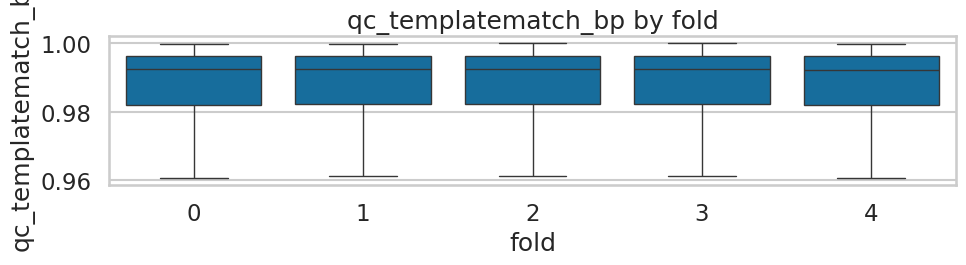


sex_norm
Categorical summary (% per fold):


sex_norm,Female,Male,NaN,Other
fold,,,,
0,59.03,40.97,0,0
1,59.04,40.96,0,0
2,59.19,40.81,0,0
3,58.74,41.26,0,0
4,59.14,40.86,0,0


Counts per fold:


sex_norm,Female,Male,NaN,Other
fold,,,,
0,43230,30007,0,0
1,43236,30001,0,0
2,43350,29888,0,0
3,43021,30216,0,0
4,43312,29924,0,0


In [58]:
from pandas.api.types import is_numeric_dtype, is_bool_dtype

# --- Choose columns to compare ---
# Exclude identifiers and path-like fields.
exclude_exact = {'exam_id', 'patient_id', 'fold', 'proc_stem', 'path', 'processed_root'}
exclude_substrings = ('path', 'root', 'stem')

cols_all = list(df.columns)
cols_excluded = set()
for c in cols_all:
    cl = c.lower()
    if c in exclude_exact:
        cols_excluded.add(c)
        continue
    if cl.endswith('_id') or cl == 'id':
        cols_excluded.add(c)
        continue
    if any(s in cl for s in exclude_substrings):
        cols_excluded.add(c)
        continue

# Prefer normalized sex if available
cols_compare = [c for c in cols_all if c not in cols_excluded]
if 'sex_norm' in df.columns and 'sex' in cols_compare:
    cols_compare = [c for c in cols_compare if c != 'sex']
    cols_compare.insert(min(1, len(cols_compare)), 'sex_norm')

print('Comparing columns (excluding IDs/paths):')
print(cols_compare)

# --- Row counts per fold ---
fold_sizes = df.groupby('fold').size().rename('n_rows')
display(fold_sizes.to_frame())

# --- Missingness per fold per column ---
missing = (
    df.groupby('fold')[cols_compare]
      .apply(lambda g: g.isna().mean())
)
missing = (missing * 100).round(2)
missing.columns = [f'{c}__missing_%' for c in missing.columns]
display(missing)

# --- Helpers for per-column summaries ---

def summarize_numeric(col: str):
    g = df.groupby('fold')[col]
    out = g.agg(
        n_non_missing='count',
        mean='mean',
        std='std',
        min='min',
        q25=lambda s: s.quantile(0.25),
        median='median',
        q75=lambda s: s.quantile(0.75),
        max='max',
    )
    out.insert(0, 'n_rows', df.groupby('fold').size())
    out['missing_%'] = (100 * (1 - out['n_non_missing'] / out['n_rows'])).round(2)

    overall = pd.Series({
        'n_rows': len(df),
        'n_non_missing': df[col].notna().sum(),
        'mean': df[col].mean(),
        'std': df[col].std(),
        'min': df[col].min(),
        'q25': df[col].quantile(0.25),
        'median': df[col].median(),
        'q75': df[col].quantile(0.75),
        'max': df[col].max(),
        'missing_%': (100 * df[col].isna().mean()),
    }, name='ALL')

    out = pd.concat([out, overall.to_frame().T], axis=0)
    return out


def summarize_categorical(col: str, top_k: int = 12):
    s = df[col].astype('string').fillna('NaN')
    top = s.value_counts(dropna=False).head(top_k).index.tolist()

    def map_other(x):
        return x if x in top else 'Other'

    mapped = s.map(map_other)

    counts = pd.crosstab(df['fold'], mapped)
    rates = (counts.T / counts.sum(axis=1)).T * 100

    # Add overall row for context
    overall_counts = mapped.value_counts(dropna=False)
    overall_counts = overall_counts.reindex(sorted(set(top + ['Other', 'NaN'])), fill_value=0)

    rates = rates.reindex(columns=overall_counts.index, fill_value=0).round(2)
    counts = counts.reindex(columns=overall_counts.index, fill_value=0)

    return counts, rates


# --- Run summaries for each column ---
MAX_CATEGORIES = 12
PLOT_NUMERIC = True

for col in cols_compare:
    print('\n' + '='*80)
    print(col)

    nunique = df[col].nunique(dropna=True)

    # Treat small-cardinality numerics as categorical (e.g., {0,1})
    if is_bool_dtype(df[col]) or (is_numeric_dtype(df[col]) and nunique <= 10 and col != 'age'):
        counts, rates = summarize_categorical(col, top_k=MAX_CATEGORIES)
        print('Categorical summary (% per fold):')
        display(rates)
        print('Counts per fold:')
        display(counts)
        continue

    if is_numeric_dtype(df[col]):
        display(summarize_numeric(col))

        if PLOT_NUMERIC:
            fig, ax = plt.subplots(1, 1, figsize=(10, 3))
            sns.boxplot(data=df, x='fold', y=col, ax=ax, showfliers=False)
            ax.set_title(f'{col} by fold')
            ax.set_xlabel('fold')
            ax.set_ylabel(col)
            plt.tight_layout()
            plt.show()
        continue

    # default: categorical/object
    counts, rates = summarize_categorical(col, top_k=MAX_CATEGORIES)
    print('Categorical summary (% per fold):')
    display(rates)
    print('Counts per fold:')
    display(counts)


## Interpretation guide

- If the **leakage check** is non-empty (same `(source, patient_id)` in multiple folds), fix folds before training/evaluation.
- If the **within-source fold shares** are close to 20% for each fold and source, then stratification is working as intended.
- If **chagas prevalence** within CODE-15 varies meaningfully by fold, revisit the stratification keys.
- If **age mean/median** or **male rate** shifts a lot between folds within the same source (or label), demographics are imbalanced.
- If **QC distributions** show fold-specific spikes (templatematch bins or Zhao 2018 categories), the preprocessing pipeline may be skewed for some folds.

Next steps (if you observe drift):
- Consider adding age-binning and/or sex into the stratification label, if that’s acceptable for your evaluation goals.
- Alternatively, keep current folds (label/source + patient-wise) and just **report** differences.


## 5) Quality × Chagas association (Fisher / FFH)
We test whether **Zhao2018 quality** is associated with **Chagas label**, stratified by dataset.
- Primary: 3×2 table (Excellent / Barely acceptable / Unacceptable × Chagas) with Monte‑Carlo FFH-style randomization p‑value.
- Secondary: 2×2 Fisher exact (Excellent vs Not‑Excellent × Chagas) with odds ratio.


In [59]:
import numpy as np
from scipy.stats import fisher_exact

# Use Zhao2018 categories
qual_col = 'qc_zhao2018_bp'
if qual_col not in df.columns:
    print(f'Missing {qual_col} in df')
else:
    qual_order = ['Excellent', 'Barely acceptable', 'Unacceptable']

    def _collapse_2x2(table3x2):
        # Excellent vs Not‑Excellent
        exc = table3x2.loc['Excellent']
        not_exc = table3x2.loc[[c for c in table3x2.index if c != 'Excellent']].sum()
        return np.array([[exc[0], exc[1]],[not_exc[0], not_exc[1]]], dtype=int)

    def _ffh_mc_pvalue(table3x2, n_iter=10000, seed=0):
        # Monte‑Carlo randomization with fixed margins (3x2)
        rng = np.random.default_rng(seed)
        table = np.asarray(table3x2, dtype=int)
        row_tot = table.sum(axis=1)
        col_tot = table.sum(axis=0)

        def chi2_stat(t):
            expected = np.outer(t.sum(axis=1), t.sum(axis=0)) / t.sum()
            with np.errstate(divide='ignore', invalid='ignore'):
                return np.nansum((t - expected) ** 2 / expected)

        obs_stat = chi2_stat(table)
        count = 0
        for _ in range(n_iter):
            c1, c2 = int(col_tot[0]), int(col_tot[1])
            x1 = rng.hypergeometric(c1, c2, int(row_tot[0]))
            y1 = row_tot[0] - x1
            c1 -= x1; c2 -= y1
            x2 = rng.hypergeometric(c1, c2, int(row_tot[1]))
            y2 = row_tot[1] - x2
            c1 -= x2; c2 -= y2
            x3, y3 = c1, c2
            sim = np.array([[x1,y1],[x2,y2],[x3,y3]], dtype=int)
            if chi2_stat(sim) >= obs_stat - 1e-12:
                count += 1
        return (count + 1) / (n_iter + 1)

    results = []
    for source in sorted(df['source'].dropna().unique()):
        sub = df[df['source'] == source].copy()
        sub = sub[[qual_col, 'chagas']].dropna()
        sub = sub[sub[qual_col].isin(qual_order)]
        if sub.empty:
            continue

        tab = pd.crosstab(sub[qual_col], sub['chagas']).reindex(index=qual_order, columns=[0,1], fill_value=0)
        tab.index.name = 'quality'
        tab.columns.name = 'chagas'

        tab2 = _collapse_2x2(tab)
        or_val, p_fisher = fisher_exact(tab2)

        p_ffh = _ffh_mc_pvalue(tab, n_iter=10000, seed=42)

        results.append({
            'source': source,
            'n': int(tab.values.sum()),
            'fisher2x2_or': or_val,
            'fisher2x2_p': p_fisher,
            'ffh_mc_p': p_ffh,
        })

        print('\nSource: ' + str(source))
        display(tab)
        print('2x2 Fisher (Excellent vs Not): OR=%.3f, p=%.3g' % (or_val, p_fisher))
        print('3x2 FFH Monte-Carlo p≈%.3g' % p_ffh)

    results_df = pd.DataFrame(results)
    display(results_df.sort_values('source'))



Source: CODE-15%


chagas,0,1
quality,,
Excellent,241976,3796
Barely acceptable,81529,2208
Unacceptable,12672,555


2x2 Fisher (Excellent vs Not): OR=1.870, p=3.94e-129
3x2 FFH Monte-Carlo p≈0.0001

Source: PTB-XL


chagas,0,1
quality,,
Excellent,14443,0
Barely acceptable,6302,0
Unacceptable,1054,0


2x2 Fisher (Excellent vs Not): OR=nan, p=1
3x2 FFH Monte-Carlo p≈1

Source: SaMi-Trop


chagas,0,1
quality,,
Excellent,0,801
Barely acceptable,0,657
Unacceptable,0,173


2x2 Fisher (Excellent vs Not): OR=nan, p=1
3x2 FFH Monte-Carlo p≈1


,source,n,fisher2x2_or,fisher2x2_p,ffh_mc_p
0,CODE-15%,342736,1.869698,3.943727e-129,0.0001
1,PTB-XL,21799,NaN,1.000000e+00,1.0000
2,SaMi-Trop,1631,NaN,1.000000e+00,1.0000


In [60]:
# --- QC shift factor (CODE‑15% pos/neg) and counterfactual PTB‑XL ---
qual_col = 'qc_zhao2018_bp'
qual_order = ['Excellent', 'Barely acceptable', 'Unacceptable']
FOLD_FILTER = 4  # set to None to use all folds

# Prefer df_q from the previous cell if available; otherwise rebuild from metadata
_df_base = None
_df_q = globals().get('df_q', None)
_df = globals().get('df', None)
if isinstance(_df_q, pd.DataFrame):
    _df_base = _df_q.copy()
elif isinstance(_df, pd.DataFrame):
    _df_base = _df.copy()
else:
    meta_path = META_PATH if 'META_PATH' in globals() else None
    if meta_path is None or not Path(meta_path).is_file():
        print('META_PATH not found; check path in notebook header.')
        _df_base = None
    else:
        _df_base = pd.read_csv(meta_path, low_memory=False)

if _df_base is not None:
    # normalize source labels (be tolerant of variants)
    source_map = {
        'CODE15': 'CODE15', 'CODE15%': 'CODE15', 'CODE-15': 'CODE15', 'CODE-15%': 'CODE15',
        'PTBXL': 'PTBXL', 'PTB-XL': 'PTBXL',
        'SAMITROP': 'SAMITROP', 'SaMi-Trop': 'SAMITROP', 'SAMI-TROP': 'SAMITROP',
    }
    if 'source_norm' not in _df_base.columns:
        _df_base['source_norm'] = _df_base['source'].map(lambda x: source_map.get(str(x), str(x)))

    # coerce chagas to 0/1
    def _to01(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        if s in ['1','true','t','yes']: return 1
        if s in ['0','false','f','no']: return 0
        try:
            v = int(float(s))
            return 1 if v == 1 else 0
        except Exception:
            return np.nan
    if 'chagas01' not in _df_base.columns:
        _df_base['chagas01'] = _df_base['chagas'].map(_to01)

    # normalize QC labels
    qual_map = {
        'excellent': 'Excellent',
        'barely acceptable': 'Barely acceptable',
        'unacceptable': 'Unacceptable',
    }
    if 'qc_norm' not in _df_base.columns:
        _df_base['qc_norm'] = _df_base[qual_col].astype(str).str.strip().str.lower().map(qual_map)

    if FOLD_FILTER is not None and 'fold' in _df_base.columns:
        _df_base = _df_base[_df_base['fold'] == FOLD_FILTER]

    def _pct_by_group(source_norm, chagas):
        sub = _df_base[(_df_base['source_norm'] == source_norm) & (_df_base['chagas01'] == chagas)]
        sub = sub[sub['qc_norm'].isin(qual_order)]
        tab = sub['qc_norm'].value_counts().reindex(qual_order).fillna(0)
        pct = (tab / tab.sum() * 100.0) if tab.sum() > 0 else tab
        return tab.astype(int), pct

    # base distributions
    code15_neg_cnt, code15_neg_pct = _pct_by_group('CODE15', 0)
    code15_pos_cnt, code15_pos_pct = _pct_by_group('CODE15', 1)
    ptbxl_neg_cnt, ptbxl_neg_pct = _pct_by_group('PTBXL', 0)
    samitrop_pos_cnt, samitrop_pos_pct = _pct_by_group('SAMITROP', 1)

    if code15_neg_pct.sum() == 0 or code15_pos_pct.sum() == 0 or ptbxl_neg_pct.sum() == 0:
        print('One or more groups empty; try FOLD_FILTER=None or check source/chagas/qc counts above.')
        print('sources:', _df_base['source_norm'].value_counts(dropna=False))
        print('chagas01 counts:', _df_base['chagas01'].value_counts(dropna=False))
        print('qc_norm counts:', _df_base['qc_norm'].value_counts(dropna=False))
    else:
        # factor vector (pos ÷ neg) from CODE‑15%
        factor = (code15_pos_pct / code15_neg_pct).replace([np.inf, -np.inf], np.nan)

        # apply to PTB‑XL neg and renormalize
        ptbxl_cf_raw = ptbxl_neg_pct * factor
        ptbxl_cf_pct = ptbxl_cf_raw / ptbxl_cf_raw.sum() * 100.0

        # summary table
        summary = pd.DataFrame({
            'CODE15 neg %': code15_neg_pct.round(2),
            'CODE15 pos %': code15_pos_pct.round(2),
            'Factor (pos/neg)': factor.round(3),
            'PTB-XL neg %': ptbxl_neg_pct.round(2),
            'PTB-XL cf pos %': ptbxl_cf_pct.round(2),
            'SaMi-Trop pos %': samitrop_pos_pct.round(2),
        })
        display(summary)

        # narrative output
        def _fmt_series(s):
            return (s.reindex(qual_order).round(2)).tolist()

        c15n = _fmt_series(code15_neg_pct)
        c15p = _fmt_series(code15_pos_pct)
        fac = _fmt_series(factor * 1.0)
        ptbn = _fmt_series(ptbxl_neg_pct)
        ptbcf = _fmt_series(ptbxl_cf_pct)
        samip = _fmt_series(samitrop_pos_pct)

        print("The CODE-15% Chagas factor (pos ÷ neg) per Zhao2018 QC bin is:")
        for label, f in zip(qual_order, fac):
            print(f"- {label}: {f:.3f}")

        def _rel_change(pos, neg):
            return (pos - neg) / neg if neg != 0 else np.nan

        print("So, relative to CODE-15% negatives, CODE-15% positives have:")
        for label, p, n in zip(qual_order, c15p, c15n):
            rc = _rel_change(p, n)
            if np.isnan(rc):
                msg = "n/a"
            elif rc >= 0:
                msg = f"~{rc*100:.0f}% more"
            else:
                msg = f"~{abs(rc)*100:.0f}% fewer"
            print(f"- {msg} {label}")

        print("PTB-XL negatives: ")
        for label, v in zip(qual_order, ptbn):
            print(f"- {label}: {v:.2f}%")

        print("If you transfer this factor to PTB-XL negatives and renormalize, expected PTB-XL-positive QC distribution:")
        for label, v in zip(qual_order, ptbcf):
            print(f"- {label}: ~{v:.1f}%")

        print("SaMi-Trop positives (observed):")
        for label, v in zip(qual_order, samip):
            print(f"- {label}: {v:.2f}%")

        print("Compare this counterfactual PTB-XL-positive distribution to observed CODE-15% and SaMi-Trop positives.")



,CODE15 neg %,CODE15 pos %,Factor (pos/neg),PTB-XL neg %,PTB-XL cf pos %,SaMi-Trop pos %
qc_norm,,,,,,
Excellent,71.63,57.92,0.809,65.84,51.01,48.72
Barely acceptable,24.47,32.52,1.329,29.09,37.04,41.99
Unacceptable,3.89,9.55,2.455,5.08,11.95,9.29


The CODE-15% Chagas factor (pos ÷ neg) per Zhao2018 QC bin is:
- Excellent: 0.810
- Barely acceptable: 1.330
- Unacceptable: 2.450
So, relative to CODE-15% negatives, CODE-15% positives have:
- ~19% fewer Excellent
- ~33% more Barely acceptable
- ~146% more Unacceptable
PTB-XL negatives: 
- Excellent: 65.84%
- Barely acceptable: 29.09%
- Unacceptable: 5.08%
If you transfer this factor to PTB-XL negatives and renormalize, expected PTB-XL-positive QC distribution:
- Excellent: ~51.0%
- Barely acceptable: ~37.0%
- Unacceptable: ~11.9%
SaMi-Trop positives (observed):
- Excellent: 48.72%
- Barely acceptable: 41.99%
- Unacceptable: 9.29%
Compare this counterfactual PTB-XL-positive distribution to observed CODE-15% and SaMi-Trop positives.


## Metadata/Dataset overview export for thesis assets

This cell exports reproducible dataset-overview figures and CSV summaries directly to thesis paths:
- `thesis/figures/generated/datasets_overview/`
- `thesis/tables/generated/datasets_overview/`

It includes fold-share heatmap, fold-4 label balance by source, and metadata-defined normal ECG summary (strict PTB-XL `NORM=100`).


In [61]:
from pathlib import Path
import ast
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve repo root (look for configs/analysis/embeddings_probe_runs.toml)
root = Path.cwd().resolve()
marker = Path('configs/analysis/embeddings_probe_runs.toml')
if not (root / marker).exists():
    for parent in root.parents:
        if (parent / marker).exists():
            root = parent
            break

physionet_root = Path(os.environ.get('PHYSIONET_ROOT', str(root.parent / 'datasets/physionet2025')))
meta_path = Path(os.environ.get('META_PATH', str(physionet_root / 'processedMaster/metadata.csv')))
code15_exams_path = physionet_root / 'code15' / 'exams.csv'
samitrop_exams_path = physionet_root / 'sami-trop' / 'exams.csv'
ptb_path = physionet_root / 'ptb-xl' / 'ptbxl_database.csv'

for req in [meta_path, code15_exams_path, samitrop_exams_path, ptb_path]:
    if not req.is_file():
        raise FileNotFoundError(f'Missing required file: {req}')

TARGET_FOLD = int(os.environ.get('TARGET_FOLD', '4'))

# Thesis-ready output locations
fig_dir = root / 'thesis/figures/generated/datasets_overview'
tbl_dir = root / 'thesis/tables/generated/datasets_overview'
fig_dir.mkdir(parents=True, exist_ok=True)
tbl_dir.mkdir(parents=True, exist_ok=True)

source_map = {
    'CODE15': 'CODE-15%', 'CODE15%': 'CODE-15%', 'CODE-15': 'CODE-15%', 'CODE-15%': 'CODE-15%',
    'PTBXL': 'PTB-XL', 'PTB-XL': 'PTB-XL',
    'SAMITROP': 'SaMi-Trop', 'SaMi-Trop': 'SaMi-Trop', 'SAMI-TROP': 'SaMi-Trop',
}
source_order = ['CODE-15%', 'SaMi-Trop', 'PTB-XL']

# -------------------------
# 1) Metadata baseline tables
# -------------------------
meta = pd.read_csv(meta_path, usecols=['exam_id', 'source', 'fold', 'chagas'], low_memory=False).copy()
meta['exam_id'] = meta['exam_id'].astype(str)
meta['source'] = meta['source'].astype(str).map(lambda x: source_map.get(x, x))
meta['fold'] = pd.to_numeric(meta['fold'], errors='coerce').astype('Int64')
meta['chagas'] = pd.to_numeric(meta['chagas'], errors='coerce').astype('Int64')

fold_counts = (
    meta.groupby(['source', 'fold'], observed=True)
    .size()
    .rename('n')
    .reset_index()
)
source_totals = fold_counts.groupby('source', observed=True)['n'].sum().rename('source_total').reset_index()
fold_counts = fold_counts.merge(source_totals, on='source', how='left')
fold_counts['pct_within_source'] = 100.0 * fold_counts['n'] / fold_counts['source_total']
fold_counts.to_csv(tbl_dir / 'fold_counts_within_source.csv', index=False)

fold4 = meta[meta['fold'] == TARGET_FOLD].copy()
fold4_counts = (
    fold4.groupby(['source', 'chagas'], observed=True)
    .size()
    .rename('n')
    .reset_index()
)
fold4_totals = fold4_counts.groupby('source', observed=True)['n'].sum().rename('source_total').reset_index()
fold4_counts = fold4_counts.merge(fold4_totals, on='source', how='left')
fold4_counts['pct_within_source'] = 100.0 * fold4_counts['n'] / fold4_counts['source_total']
fold4_counts.to_csv(tbl_dir / f'fold{TARGET_FOLD}_source_label_counts.csv', index=False)

# -------------------------
# 2) Fold-share heatmap by source
# -------------------------
heat = fold_counts.pivot(index='source', columns='fold', values='pct_within_source')
heat = heat.reindex(source_order)

plt.figure(figsize=(6.6, 2.3))
ax = sns.heatmap(
    heat,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.3,
    vmin=18,
    vmax=22,
    cbar_kws={'label': '%', 'shrink': 0.92, 'pad': 0.02},
)
ax.set_title('Fold share by source', fontsize=10)
ax.set_xlabel('Fold', fontsize=9)
ax.set_ylabel('Source', fontsize=9)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout(rect=(0, 0, 0.86, 1))
fold_share_path = fig_dir / 'fold_share_by_source_heatmap.png'
plt.savefig(fold_share_path, dpi=220)
plt.close()

# -------------------------
# 3) Fold-4 label balance by source
# -------------------------
plot_fold4 = fold4_counts.copy()
plot_fold4['label'] = plot_fold4['chagas'].map({0: 'Chagas=0', 1: 'Chagas=1'}).fillna('Unknown')
plot_fold4['source'] = pd.Categorical(plot_fold4['source'], categories=source_order, ordered=True)
plot_fold4 = plot_fold4.sort_values(['source', 'label'])

plt.figure(figsize=(6.8, 3.0))
ax = sns.barplot(
    data=plot_fold4,
    x='source',
    y='pct_within_source',
    hue='label',
    palette=['#4C72B0', '#DD8452', '#999999'],
)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)
ax.set_ylim(0, 100)
ax.set_ylabel('Share within source (%)', fontsize=9)
ax.set_xlabel('Source', fontsize=9)
ax.set_title('', fontsize=10)
ax.legend(title='Label', loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8, title_fontsize=9)
ax.grid(axis='y', alpha=0.25)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout(rect=(0, 0, 0.86, 1))
label_bal_path = fig_dir / f'fold{TARGET_FOLD}_label_balance_by_source.png'
plt.savefig(label_bal_path, dpi=220)
plt.close()

# -------------------------
# 4) Metadata-defined ECG normality by source (fold 4)
# -------------------------
meta_fold = pd.read_csv(meta_path, usecols=['exam_id', 'source', 'fold'], low_memory=False)
meta_fold['exam_id'] = meta_fold['exam_id'].astype(str)
meta_fold['source'] = meta_fold['source'].astype(str).map(lambda x: source_map.get(x, x))
meta_fold = meta_fold[meta_fold['fold'] == TARGET_FOLD].copy()

code15 = pd.read_csv(code15_exams_path, usecols=['exam_id', 'normal_ecg'])
code15['exam_id'] = code15['exam_id'].astype(str)
code15['source'] = 'CODE-15%'

sami = pd.read_csv(samitrop_exams_path, usecols=['exam_id', 'normal_ecg'])
sami['exam_id'] = sami['exam_id'].astype(str)
sami['source'] = 'SaMi-Trop'

ptb = pd.read_csv(ptb_path, usecols=['ecg_id', 'scp_codes'])
ptb['exam_id'] = ptb['ecg_id'].astype(str) + '_hr'

def has_norm_100(val):
    if pd.isna(val):
        return False
    try:
        d = ast.literal_eval(str(val))
    except Exception:
        return False
    if not isinstance(d, dict):
        return False
    if 'NORM' not in d:
        return False
    try:
        return float(d.get('NORM', 0.0)) == 100.0
    except Exception:
        return False

ptb['normal_ecg'] = ptb['scp_codes'].map(has_norm_100)
ptb['source'] = 'PTB-XL'

norm = pd.concat([
    code15[['exam_id', 'source', 'normal_ecg']],
    sami[['exam_id', 'source', 'normal_ecg']],
    ptb[['exam_id', 'source', 'normal_ecg']],
], ignore_index=True)

merged = meta_fold.merge(norm, on=['exam_id', 'source'], how='inner')
merged['normal_ecg'] = merged['normal_ecg'].fillna(False).astype(bool)
merged['ecg_state'] = merged['normal_ecg'].map({True: 'Normal ECG', False: 'Not normal ECG'})

summary = (
    merged.groupby(['source', 'ecg_state'], observed=True)
    .size()
    .rename('n')
    .reset_index()
)
summary['source_total'] = summary.groupby('source')['n'].transform('sum')
summary['pct'] = 100.0 * summary['n'] / summary['source_total']

state_order = ['Normal ECG', 'Not normal ECG']
summary['source'] = pd.Categorical(summary['source'], categories=source_order, ordered=True)
summary['ecg_state'] = pd.Categorical(summary['ecg_state'], categories=state_order, ordered=True)
summary = summary.sort_values(['source', 'ecg_state']).reset_index(drop=True)
summary.to_csv(tbl_dir / f'fold{TARGET_FOLD}_metadata_normal_ecg_by_source.csv', index=False)

pivot = summary.pivot(index='source', columns='ecg_state', values='pct').reindex(source_order)
pivot = pivot.reindex(columns=state_order).fillna(0.0)

x = np.arange(len(source_order))
width = 0.35
fig, ax = plt.subplots(figsize=(6.8, 3.2))
normal_vals = pivot['Normal ECG'].to_numpy()
not_vals = pivot['Not normal ECG'].to_numpy()

bars1 = ax.bar(x - width / 2, normal_vals, width, label='Normal ECG', color='#4C72B0')
bars2 = ax.bar(x + width / 2, not_vals, width, label='Not normal ECG', color='#DD8452')

ax.bar_label(bars1, fmt='%.1f%%', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.1f%%', padding=2, fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(source_order)
ax.set_xlabel('Dataset source', fontsize=9)
ax.set_ylabel('Share (%)', fontsize=9)
ax.set_ylim(0, 100)
ax.set_title('', fontsize=10)
ax.legend(title='ECG state', loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, fontsize=8, title_fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='both', labelsize=8)
fig.tight_layout(rect=(0, 0, 0.86, 1))

normal_fig_path = fig_dir / f'fold{TARGET_FOLD}_metadata_normal_ecg_by_source.png'
fig.savefig(normal_fig_path, dpi=220)
plt.close(fig)

# -------------------------
# 5) Helper TeX include snippet
# -------------------------
tex_path = fig_dir / 'datasets_overview_assets.tex'
tex = f"""% Auto-generated from datasets.ipynb
% Figures directory: thesis/figures/generated/datasets_overview
% Tables directory : thesis/tables/generated/datasets_overview

% Recommended includes:
% \\includegraphics[width=0.75\textwidth]{{figures/generated/datasets_overview/fold_share_by_source_heatmap.png}}
% \\includegraphics[width=0.75\textwidth]{{figures/generated/datasets_overview/fold{TARGET_FOLD}_label_balance_by_source.png}}
% \\includegraphics[width=0.75\textwidth]{{figures/generated/datasets_overview/fold{TARGET_FOLD}_metadata_normal_ecg_by_source.png}}
"""
tex_path.write_text(tex)

print('Saved figures:')
print(' -', fold_share_path)
print(' -', label_bal_path)
print(' -', normal_fig_path)
print('Saved tables:')
print(' -', tbl_dir / 'fold_counts_within_source.csv')
print(' -', tbl_dir / f'fold{TARGET_FOLD}_source_label_counts.csv')
print(' -', tbl_dir / f'fold{TARGET_FOLD}_metadata_normal_ecg_by_source.csv')
print('Saved TeX helper:')
print(' -', tex_path)

display(summary)








/tmp/ipykernel_220301/1758788346.py:111: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  ax = sns.barplot(


Saved figures:
 - /home/flo178/projects/master-thesis/ecg-chagas-embeddings/thesis/figures/generated/datasets_overview/fold_share_by_source_heatmap.png
 - /home/flo178/projects/master-thesis/ecg-chagas-embeddings/thesis/figures/generated/datasets_overview/fold4_label_balance_by_source.png
 - /home/flo178/projects/master-thesis/ecg-chagas-embeddings/thesis/figures/generated/datasets_overview/fold4_metadata_normal_ecg_by_source.png
Saved tables:
 - /home/flo178/projects/master-thesis/ecg-chagas-embeddings/thesis/tables/generated/datasets_overview/fold_counts_within_source.csv
 - /home/flo178/projects/master-thesis/ecg-chagas-embeddings/thesis/tables/generated/datasets_overview/fold4_source_label_counts.csv
 - /home/flo178/projects/master-thesis/ecg-chagas-embeddings/thesis/tables/generated/datasets_overview/fold4_metadata_normal_ecg_by_source.csv
Saved TeX helper:
 - /home/flo178/projects/master-thesis/ecg-chagas-embeddings/thesis/figures/generated/datasets_overview/datasets_overview_ass

,source,ecg_state,n,source_total,pct
0,CODE-15%,Normal ECG,26807,68592,39.081817
1,CODE-15%,Not normal ECG,41785,68592,60.918183
2,SaMi-Trop,Normal ECG,56,312,17.948718
3,SaMi-Trop,Not normal ECG,256,312,82.051282
4,PTB-XL,Normal ECG,720,2338,30.795552
5,PTB-XL,Not normal ECG,1618,2338,69.204448
